# Old CRC Variance Analysis

Analyze the relationship between per-gene Pearson r and multiple gene statistics for the old 1000-gene CRC experiment (MorphPT+LoRA MLP 10×).

**Goal:** Understand whether variance/CV explains predictability better than coverage.

**Sections:**
1. Setup & find paths
2. Load per-gene Pearson r from old experiment
3. Compute per-gene statistics (coverage, mean, std, CV)
4. Correlation analysis
5. Visualization
6. Coverage bin analysis
7. Key findings summary

## 1. Setup & Find Paths

In [12]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.ndimage import uniform_filter1d

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})
print('Setup done.')

Setup done.


In [11]:
# Find the old experiment directory
print('Searching for old CRC experiment with per_gene_pearson_test.pt...')
for exp in sorted((PROJECT / 'experiments').glob('visium_morphpt*')):
    f = exp / 'per_gene_pearson_test.pt'
    if f.exists():
        pg = torch.load(f, map_location='cpu').numpy()
        # Also check if crc in name and not randsplit
        suffix = '_crc' in exp.name or exp.name.endswith(('mlp', 'gate', 'gate_mlp', '10x', '25x'))
        not_rand = 'randsplit' not in exp.name
        marker = ' ← candidate (old 1000-gene)' if (len(pg) == 1000 and not_rand) else ''
        print(f'  {exp.name:<50} n_genes={len(pg)}  mean_r={pg.mean():.4f}{marker}')

Searching for old CRC experiment with per_gene_pearson_test.pt...


/tmp/ipykernel_35056/3650763906.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pg = torch.load(f, map_location='cpu').numpy()


  visium_morphpt_10x                                 n_genes=1000  mean_r=0.1869 ← candidate (old 1000-gene)
  visium_morphpt_10x_mlp                             n_genes=1000  mean_r=0.2160 ← candidate (old 1000-gene)
  visium_morphpt_25x                                 n_genes=1000  mean_r=0.1434 ← candidate (old 1000-gene)
  visium_morphpt_25x_mlp                             n_genes=1000  mean_r=0.1644 ← candidate (old 1000-gene)
  visium_morphpt_gate                                n_genes=1000  mean_r=0.2030 ← candidate (old 1000-gene)
  visium_morphpt_gate_mlp                            n_genes=1000  mean_r=0.2282 ← candidate (old 1000-gene)
  visium_morphpt_lora_10x                            n_genes=1000  mean_r=0.2566 ← candidate (old 1000-gene)
  visium_morphpt_lora_10x_mlp                        n_genes=1000  mean_r=0.2632 ← candidate (old 1000-gene)
  visium_morphpt_lora_10x_mlp_crc                    n_genes=2220  mean_r=0.1879
  visium_morphpt_lora_10x_mlp_crc_randsplit    

In [2]:
# Set the experiment path (change if needed based on output above)
OLD_EXP_DIR = PROJECT / 'experiments/visium_morphpt_lora_10x_mlp'   # 1000 genes, MLP 10x

# Find old cache (1000-gene dataset)
# Check common locations
CANDIDATES = [
    Path('/hpc/group/jilab/rz179/MorphPT_MOE/cache_visium'),
    PROJECT / 'cache_visium',
    PROJECT / 'cache_crc_old',
]

expr_path = '/hpc/group/jilab/rz179/MorphPT_MOE/cache_visium/expr.npy'
if expr_path.exists():
    expr = np.load(str(expr_path), mmap_mode='r')
    print(f'  expr shape: {expr.shape}')

✓ Found 1000-gene cache: /hpc/group/jilab/rz179/MorphPT_MOE/cache_visium
  expr shape: (185555, 1000)


## 2. Load Per-Gene Pearson r

In [3]:
test_r = torch.load(OLD_EXP_DIR / 'per_gene_pearson_test.pt',
                    map_location='cpu').numpy()

print(f'Loaded: {len(test_r)} genes')
print(f'  mean_r   = {test_r.mean():.4f}')
print(f'  median_r = {np.median(test_r):.4f}')
print(f'  r > 0.1  = {(test_r > 0.1).sum()} / {len(test_r)}')
print(f'  r > 0.2  = {(test_r > 0.2).sum()} / {len(test_r)}')
print(f'  r > 0.3  = {(test_r > 0.3).sum()} / {len(test_r)}')

Loaded: 1000 genes
  mean_r   = 0.2632
  median_r = 0.2354
  r > 0.1  = 965 / 1000
  r > 0.2  = 649 / 1000
  r > 0.3  = 292 / 1000


/tmp/ipykernel_35056/1015508496.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_r = torch.load(OLD_EXP_DIR / 'per_gene_pearson_test.pt',


## 3. Compute Per-Gene Statistics

In [4]:
print(f'Loading expression data from {OLD_CACHE}...')
expr = np.load(str(OLD_CACHE / 'expr.npy'), mmap_mode='r')
meta = pd.read_csv(OLD_CACHE / 'meta.csv')

print(f'  expr shape: {expr.shape}')
print(f'  meta cols : {meta.columns.tolist()}')
print(f'  splits    : {meta["split"].value_counts().to_dict()}')

train_idx = np.sort(meta[meta['split'] == 'train']['mmap_idx'].values)
print(f'  train cells: {len(train_idx):,}')

Loading expression data from /hpc/group/jilab/rz179/MorphPT_MOE/cache_visium...
  expr shape: (185555, 1000)
  meta cols : ['cell_id', 'x_centroid', 'y_centroid', 'mmap_idx', 'x_bin', 'y_bin', 'tile_id', 'split']
  splits    : {'train': 133829, 'test': 31459, 'val': 20267}
  train cells: 133,829


In [5]:
# Compute per-gene stats on train cells (batched to avoid OOM)
n_genes = expr.shape[1]
sum_x   = np.zeros(n_genes, dtype=np.float64)
sum_x2  = np.zeros(n_genes, dtype=np.float64)
sum_nz  = np.zeros(n_genes, dtype=np.float64)

batch = 5000
for i in range(0, len(train_idx), batch):
    X = expr[train_idx[i:i+batch]].astype(np.float64)
    sum_x  += X.sum(axis=0)
    sum_x2 += (X ** 2).sum(axis=0)
    sum_nz += (X > 0).sum(axis=0)

n_train       = len(train_idx)
gene_mean     = sum_x / n_train
gene_var      = np.clip((sum_x2 / n_train) - (gene_mean ** 2), 0, None)
gene_std      = np.sqrt(gene_var)
gene_cv       = gene_std / np.clip(gene_mean, 1e-5, None)
gene_coverage = sum_nz / n_train

print(f'Per-gene stats on {n_train:,} train cells:')
print(f'  coverage : [{gene_coverage.min():.3f}, {gene_coverage.max():.3f}]  mean={gene_coverage.mean():.3f}')
print(f'  mean_expr: [{gene_mean.min():.3f}, {gene_mean.max():.3f}]')
print(f'  std_expr : [{gene_std.min():.3f}, {gene_std.max():.3f}]')
print(f'  CV       : [{gene_cv.min():.3f}, {gene_cv.max():.3f}]')

Per-gene stats on 133,829 train cells:
  coverage : [0.009, 0.534]  mean=0.066
  mean_expr: [0.023, 1.593]
  std_expr : [0.244, 2.220]
  CV       : [0.984, 10.578]


In [6]:
# Build the results DataFrame
df = pd.DataFrame({
    'gene_idx':   np.arange(n_genes),
    'test_r':     test_r,
    'coverage':   gene_coverage,
    'mean_expr':  gene_mean,
    'std_expr':   gene_std,
    'cv':         gene_cv,
})

# Add gene names if available
for fname in ['gene_list.txt', 'genes.txt']:
    if (OLD_CACHE / fname).exists():
        genes = (OLD_CACHE / fname).read_text().splitlines()
        if len(genes) == n_genes:
            df.insert(1, 'gene_name', genes)
            print(f'Loaded gene names from {fname}')
            break

df.head(10)

,gene_idx,test_r,coverage,mean_expr,std_expr,cv
0,0,0.369884,0.048121,0.175972,0.849918,4.829847
1,1,0.182170,0.034133,0.128701,0.741464,5.761127
2,2,0.573658,0.136420,0.511569,1.418245,2.772342
3,3,0.409146,0.023127,0.073465,0.500284,6.809814
4,4,0.321804,0.024449,0.088609,0.591178,6.671769
5,5,0.664485,0.384976,1.484428,2.219568,1.495234
6,6,0.524467,0.037010,0.137555,0.738415,5.368161
7,7,0.684236,0.103610,0.394202,1.228703,3.116938
8,8,0.851982,0.072996,0.283165,1.064108,3.757909
9,9,0.895143,0.119473,0.562862,1.583091,2.812573


## 4. Correlation Analysis

In [7]:
print(f'Correlation between per-gene stats and test Pearson r:')
print(f'{"="*65}')
print(f'{"Metric":<20} {"Pearson":>10} {"Spearman":>10} {"p-value":>12}')
print('-' * 65)

corr_results = []
for col, label in [('coverage', 'Coverage (%)'),
                   ('mean_expr', 'Mean expression'),
                   ('std_expr', 'Std expression (variance!)'),
                   ('cv', 'CV (std/mean)')]:
    r, p     = stats.pearsonr(df[col], df['test_r'])
    r_sp, _  = stats.spearmanr(df[col], df['test_r'])
    print(f'{label:<20} {r:>+10.4f} {r_sp:>+10.4f} {p:>12.2e}')
    corr_results.append({'metric': col, 'pearson': r,
                         'spearman': r_sp, 'pvalue': p})

print(f'\n→ Higher correlation = better predictor of gene predictability')

Correlation between per-gene stats and test Pearson r:
Metric                  Pearson   Spearman      p-value
-----------------------------------------------------------------
Coverage (%)            +0.3007    +0.2716     2.40e-22
Mean expression         +0.3942    +0.3462     1.64e-38
Std expression (variance!)    +0.5126    +0.4257     4.38e-68
CV (std/mean)           -0.2933    -0.2731     2.73e-21

→ Higher correlation = better predictor of gene predictability


## 5. Visualization: test_r vs each statistic

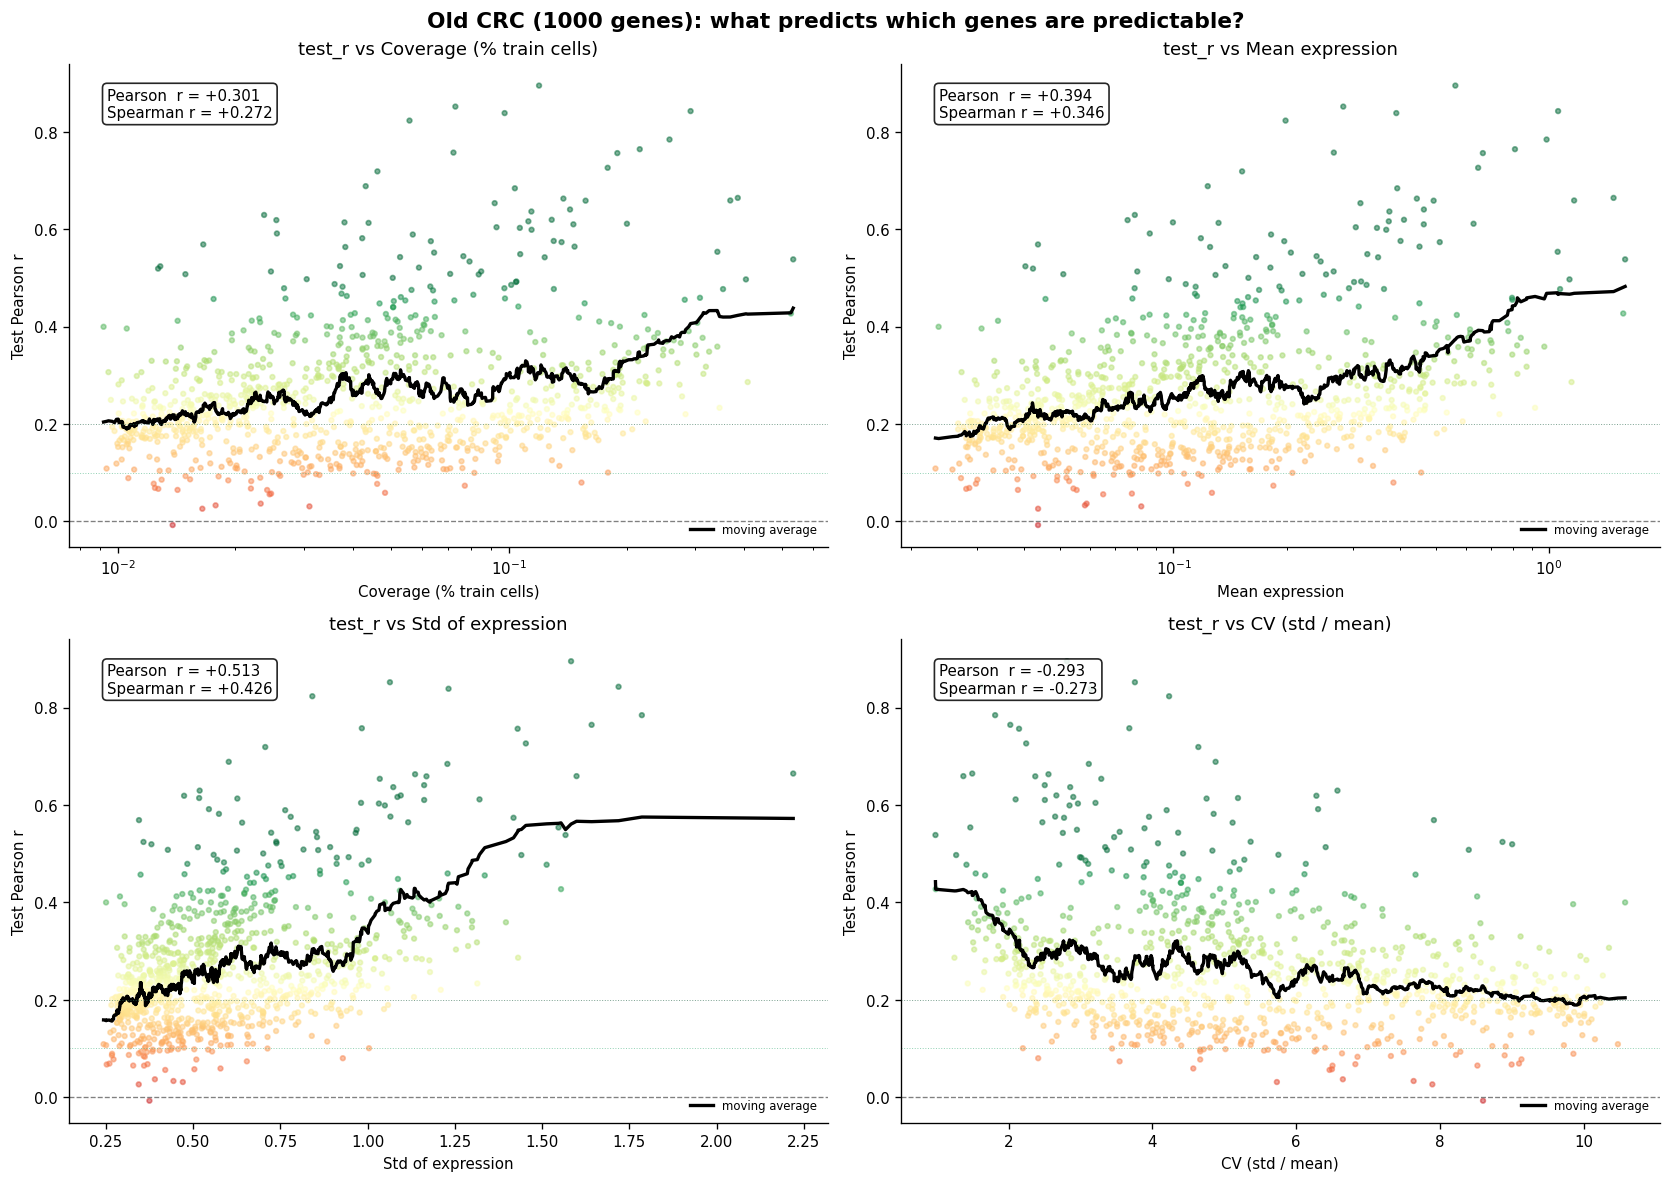

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_plot = [
    ('coverage',  'Coverage (% train cells)',   True),
    ('mean_expr', 'Mean expression',            True),
    ('std_expr',  'Std of expression',          False),
    ('cv',        'CV (std / mean)',            False),
]

for ax, (col, label, logx) in zip(axes.flat, metrics_plot):
    # Scatter
    sc = ax.scatter(df[col], df['test_r'],
                    c=df['test_r'], cmap='RdYlGn',
                    vmin=-0.05, vmax=0.5, s=8, alpha=0.5,
                    rasterized=True)
    if logx and df[col].min() > 0:
        ax.set_xscale('log')

    # Smooth trend line
    sort_idx = np.argsort(df[col].values)
    window   = max(20, len(df) // 25)
    smooth   = uniform_filter1d(df['test_r'].values[sort_idx], size=window)
    ax.plot(df[col].values[sort_idx], smooth, color='black',
            lw=2, label='moving average')

    # Correlations
    r,    _ = stats.pearsonr(df[col], df['test_r'])
    r_sp, _ = stats.spearmanr(df[col], df['test_r'])
    ax.text(0.05, 0.95,
            f'Pearson  r = {r:+.3f}\n'
            f'Spearman r = {r_sp:+.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.axhline(0,   color='gray', lw=0.8, ls='--')
    ax.axhline(0.1, color='#52b788', lw=0.6, ls=':', alpha=0.6)
    ax.axhline(0.2, color='#2d6a4f', lw=0.6, ls=':', alpha=0.6)
    ax.set_xlabel(label)
    ax.set_ylabel('Test Pearson r')
    ax.set_title(f'test_r vs {label}')
    ax.legend(loc='lower right', fontsize=7)

fig.suptitle('Old CRC (1000 genes): what predicts which genes are predictable?',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Coverage vs Variance — which matters more?

Do a controlled comparison: fix coverage, vary variance, and vice versa.

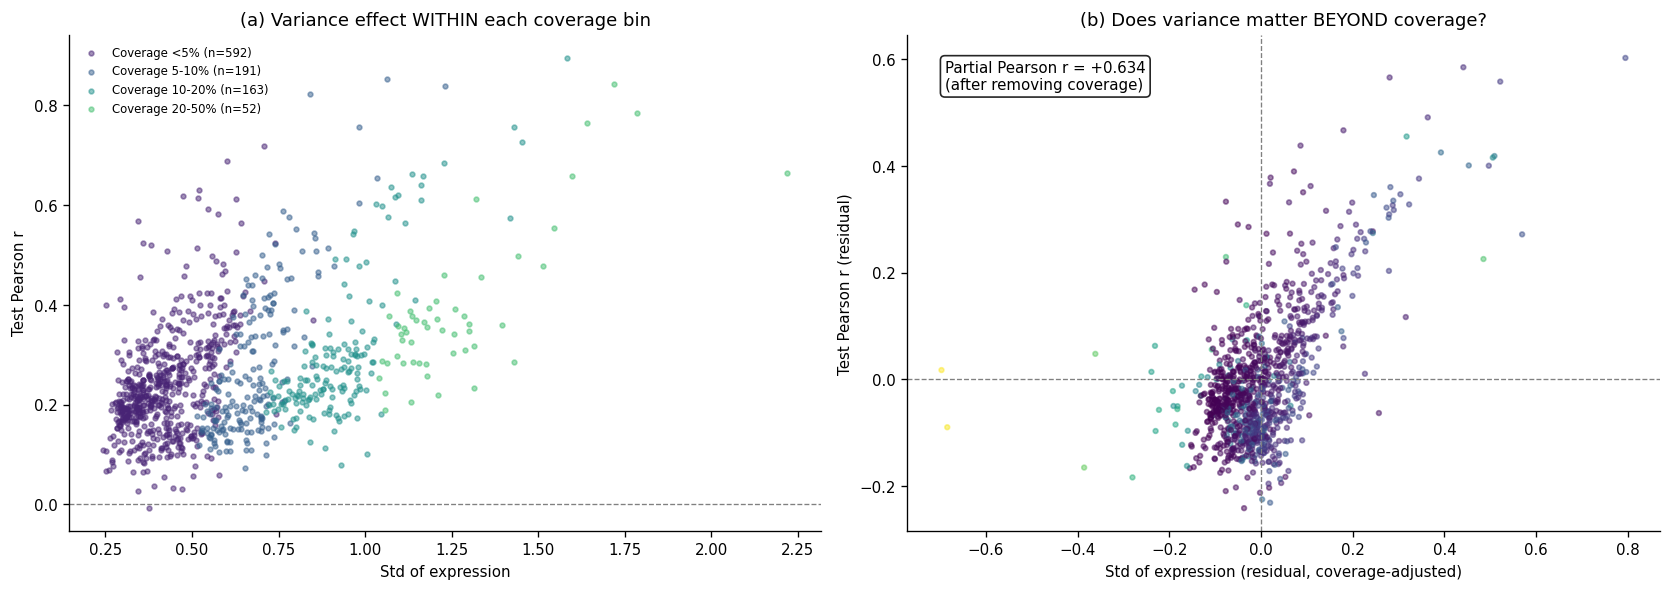

Partial correlation of std_expr with test_r (after controlling for coverage):
  r = +0.6336  p = 2.37e-113
  → Variance DOES provide additional information beyond coverage


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Group by coverage bin, show variance effect within each bin
ax   = axes[0]
bins = [0, 0.05, 0.10, 0.20, 0.50, 1.01]
labs = ['<5%', '5-10%', '10-20%', '20-50%', '>50%']
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(labs)))

for i in range(len(labs)):
    mask = (df['coverage'] >= bins[i]) & (df['coverage'] < bins[i+1])
    sub  = df[mask]
    if len(sub) < 10:
        continue
    ax.scatter(sub['std_expr'], sub['test_r'],
               s=8, alpha=0.5, color=colors[i],
               label=f'Coverage {labs[i]} (n={len(sub)})')

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Std of expression')
ax.set_ylabel('Test Pearson r')
ax.set_title('(a) Variance effect WITHIN each coverage bin')
ax.legend(fontsize=7)

# (b) Partial correlation (remove coverage from variance)
from sklearn.linear_model import LinearRegression

# Residualize std_expr w.r.t. coverage
X = df[['coverage']].values
y_std = df['std_expr'].values
std_resid = y_std - LinearRegression().fit(X, y_std).predict(X)

# Residualize test_r w.r.t. coverage
y_r = df['test_r'].values
r_resid = y_r - LinearRegression().fit(X, y_r).predict(X)

ax = axes[1]
ax.scatter(std_resid, r_resid, c=df['coverage'], cmap='viridis',
           s=8, alpha=0.5, rasterized=True)

# Correlation after removing coverage
r_partial, p_partial = stats.pearsonr(std_resid, r_resid)
ax.text(0.05, 0.95,
        f'Partial Pearson r = {r_partial:+.3f}\n(after removing coverage)',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Std of expression (residual, coverage-adjusted)')
ax.set_ylabel('Test Pearson r (residual)')
ax.set_title('(b) Does variance matter BEYOND coverage?')

fig.tight_layout()
plt.show()

print(f'Partial correlation of std_expr with test_r (after controlling for coverage):')
print(f'  r = {r_partial:+.4f}  p = {p_partial:.2e}')
if abs(r_partial) > 0.1:
    print(f'  → Variance DOES provide additional information beyond coverage')
else:
    print(f'  → Variance provides little additional info beyond coverage')

## 7. Summary & Key Findings

In [10]:
print(f'{"="*65}')
print(f'SUMMARY: What predicts gene predictability (old CRC, 1000 genes)?')
print(f'{"="*65}')
print()
print(f'Experiment  : MorphPT+LoRA MLP 10× (spatial split)')
print(f'Dataset     : Old CRC 1000 genes')
print(f'n_genes     : {len(df)}')
print(f'Mean Pearson r: {df["test_r"].mean():.4f}')
print()
print(f'Correlation with test_r:')
for r in corr_results:
    print(f'  {r["metric"]:<12} Pearson={r["pearson"]:+.3f}  Spearman={r["spearman"]:+.3f}')

print(f'\nPartial correlation (variance | coverage): {r_partial:+.4f}')
print()

# Top 10 genes by each metric
print(f'Top 10 best predicted genes:')
cols_show = ['gene_name'] if 'gene_name' in df.columns else ['gene_idx']
cols_show += ['coverage', 'std_expr', 'cv', 'test_r']
print(df.nlargest(10, 'test_r')[cols_show].to_string(index=False))

print(f'\nBottom 10 worst predicted genes:')
print(df.nsmallest(10, 'test_r')[cols_show].to_string(index=False))

# Save
out_csv = PROJECT / 'analysis/old_crc_variance_analysis.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_csv, index=False)
print(f'\nSaved full results → {out_csv}')

SUMMARY: What predicts gene predictability (old CRC, 1000 genes)?

Experiment  : MorphPT+LoRA MLP 10× (spatial split)
Dataset     : Old CRC 1000 genes
n_genes     : 1000
Mean Pearson r: 0.2632

Correlation with test_r:
  coverage     Pearson=+0.301  Spearman=+0.272
  mean_expr    Pearson=+0.394  Spearman=+0.346
  std_expr     Pearson=+0.513  Spearman=+0.426
  cv           Pearson=-0.293  Spearman=-0.273

Partial correlation (variance | coverage): +0.6336

Top 10 best predicted genes:
 gene_idx  coverage  std_expr       cv   test_r
        9  0.119473  1.583091 2.812573 0.895143
        8  0.072996  1.064108 3.757909 0.851982
       61  0.291596  1.719203 1.627094 0.842716
       11  0.097557  1.232048 3.143427 0.838624
       15  0.055720  0.841765 4.233898 0.823250
       16  0.257538  1.785895 1.813748 0.784370
       13  0.216156  1.641980 2.024383 0.764501
       19  0.072182  0.983607 3.680411 0.757525
       41  0.189428  1.430049 2.146527 0.756478
       20  0.178960  1.453514 2